# CNN Training Using a Custom Dataset
![](https://drive.google.com/uc?id=1n1ad5alG5W1wdLk1NusbEV-m_jlHDVKL)

In [ ]:
# See prev .ipynb, few part is recap here

In [ ]:
import torch
import os
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [31]:
!unzip '/content/Classification_dataset_v3.zip'

Archive:  /content/Classification_dataset_v3.zip
   creating: Classification_dataset_v3/
  inflating: Classification_dataset_v3/Dataset_info.txt  
   creating: Classification_dataset_v3/images/
   creating: Classification_dataset_v3/images/test/
   creating: Classification_dataset_v3/images/test/Cat/
  inflating: Classification_dataset_v3/images/test/Cat/cat_1000.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1001.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1002.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1003.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1004.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1005.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1006.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1007.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1008.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1009.jpg 

In [32]:
image_dir = '/content/Classification_dataset_v3/images/train'
for label, class_dir in enumerate(os.listdir(image_dir)):
  print(label, class_dir)

0 Cat
1 Dog
2 person


In [ ]:
class ImageDataset(Dataset):
  def __init__(self, image_dir, transform=None):
    self.image_dir = image_dir
    self.image_paths = []
    self.labels = []
    self.class_name = {}
    self.transform = transform

    for label, class_dir in enumerate(os.listdir(image_dir)):
      self.class_name[label] = class_dir
      class_path = os.path.join(image_dir, class_dir)
      for img_name in os.listdir(class_path):
        self.image_paths.append(os.path.join(class_path, img_name))
        self.labels.append(label)

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, idx):
    img_path = self.image_paths[idx]
    image = Image.open(img_path).convert("RGB") #check torchvision
    label = self.labels[idx]

    if self.transform:
      image = self.transform(image)

    return image, label

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])] # not in prev ipynb, resnet, imagenet used normalize mean and std
)
# mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

In [36]:
train_image_dir = '/content/Classification_dataset_v3/images/train'
test_image_dir = '/content/Classification_dataset_v3/images/test'

train_image_dataset = ImageDataset(image_dir=train_image_dir, transform=transform)
test_image_dataset = ImageDataset(image_dir=test_image_dir, transform=transform)

In [ ]:
train_image_loader = DataLoader(dataset=train_image_dataset, batch_size=32, shuffle=True)
test_image_loader = DataLoader(dataset=test_image_dataset, batch_size=32, shuffle=True)

In [37]:
for images,labels in train_image_loader:
  print(images.shape, labels.shape)
  break

torch.Size([32, 3, 128, 128]) torch.Size([32])


In [38]:
import matplotlib.pyplot as plt
import numpy as np

In [39]:
print(train_image_dataset.class_name)
print(test_image_dataset.class_name)

{0: 'Cat', 1: 'Dog', 2: 'person'}
{0: 'Cat', 1: 'Dog', 2: 'person'}


torch.Size([32, 3, 128, 128]) torch.Size([32])
(3, 128, 128)
Dog
(128, 128, 3)
1


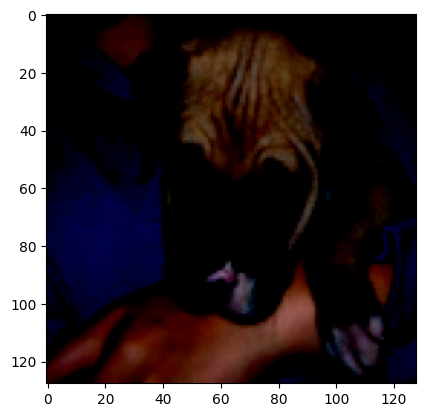

In [46]:
for images, labels in train_image_loader:
  print(images.shape, labels.shape)
  img = images[0].numpy()
  print(img.shape)
  label = labels[0].item()
  print(train_image_dataset.class_name[label])
  img = np.transpose(img, (1,2,0))
  print(img.shape)
  print(label)
  plt.imshow(img)
  break

# Custom CNN Architecture

In [47]:
import torch.nn as nn
import torch.optim as optim

In [ ]:
class CustomCnnModel(nn.Module):
  def __init__(self,input_dim, num_classes):
    super(CustomCnnModel, self).__init__()
    self.input_dim = input_dim
    self.num_classes = num_classes

    self.conv_layers = nn.Sequential(
        # C1
        nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # rgb(no of input feature) =3, no of output festures =32 
        # 128x128x3 --> 3x3x3x32 --> wxhx32
        nn.BatchNorm2d(32), # batch normisation on no of output channel
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C2
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C3
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C4
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2) # now here after this we want what is size of output from here to pass it to ANN fully connected layer
    )

    self._to_linear = None
    self._get_conv_output(self.input_dim) # so these two step used to find that output size

    # CNN layers excract important features and now ANN is used to learn it and ued as prediction of classes for new dataset
    self.fc_layers = nn.Sequential(
        nn.Linear(self._to_linear, 512),
        nn.ReLU(),
        # nn.Dropout(0.2)
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Linear(128, self.num_classes),
    )

    # 256 x 12 x 12

  def _get_conv_output(self, input_dim=128):
    with torch.no_grad():
      dummy_input = torch.zeros(1,3, input_dim, input_dim) # dummay image but size of image is same as we are going to pass it through actual image
      # batch size =1, no of channel =3, (pytorch aspect image to be pass in batch)
      output = self.conv_layers(dummy_input)
      self._to_linear = output.view(1, -1).size(1) # first flattened the value using view 
      # [1,124577] so only concern is 124577 i.e size(1)

  def forward(self,x):
    x = self.conv_layers(x) # First CNN layers 
    x = x.view(x.size(0), -1) # then flattened the value 
    x = self.fc_layers(x) # then use the fc layer ANN
    return x

In [49]:
# Initialize Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomCnnModel(input_dim=128, num_classes=3).to(device)

In [50]:
print(model)

CustomCnnModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [51]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [ ]:
# 100 epoch

# 1000
# 10 batch size
# 100

# 1 epoch --> 100 iteration
# 2 epoch --> 100 iteration

In [52]:
len(train_image_loader)

95

In [ ]:
# Training loop
epochs = 2
for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for images, labels in train_image_loader:
    images,labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    # [x, 3, 128, 128] --> x is batch size here

    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  print(f"Epoch {epoch+1}/{epochs}, Loss : {running_loss/len(train_image_loader)}")


Epoch 1/2, Loss : 0.5477533437703785
Epoch 2/2, Loss : 0.47687699669285827


In [55]:
torch.save(model.state_dict(), "cnn_model.pth")

In [57]:
for images, labels in test_image_loader:
  print(labels.shape)
  break

torch.Size([32])


In [ ]:
# Evaluate model

model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images, labels in test_image_loader:
    images,labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1) # for each image , output have all neuron value and pick max neuron index , see note below also
    # and we need to pick highest one value which has its image classes
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f"Test accuracy is :{100* correct / total:.2f}%")


Test accuracy is :74.50%


In [ ]:
'''
In Python (especially in PyTorch machine learning code), 
the underscore _ is a standard naming convention for a throwaway variable—
a value returned by a function that you deliberately choose to ignore.

Here is what each component represents:

What torch.max(..., 1) returns: When finding the maximum along class dimensions (dimension 1), 
PyTorch returns a named tuple containing two tensors:

The maximum values themselves (the highest logits or probabilities).

The indices where those maximum values occur (the class IDs).

The role of _: This captures the maximum probability/logit values. 
Since model evaluation or accuracy calculation usually only requires knowing which class was predicted (the index), 
the actual score is not needed and gets discarded into _.

The role of predicted: This captures the indices corresponding to the winning class, 
which represent the actual predicted labels (e.g., 0, 1, 2 for a multi-class task).
'''

In [59]:
import cv2

In [66]:
class ImageClassifier:
  def __init__(self, model_path, class_names):
    self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    self.model = CustomCnnModel(input_dim=128, num_classes=3).to(self.device)
    self.model.load_state_dict(torch.load(model_path, map_location=self.device))
    self.model.eval()
    self.class_names = class_names
    self.transform = transforms.Compose([
      transforms.Resize((128,128)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])]
    )

  def predict(self, image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = self.transform(image).unsqueeze(0).to(self.device)
    with torch.no_grad():
      output = self.model(input_tensor)
      _, predicted = torch.max(output, 1)
    label = self.class_names[predicted.item()]

    img = cv2.imread(image_path)
    cv2.putText(img, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    cv2.imwrite("output_image.jpg",img)
    return label



In [67]:
classfier = ImageClassifier("/content/saved/cnn_model.pth", train_image_dataset.class_name )
label = classfier.predict("/content/Classification_dataset_v3/images/test/Dog/dog_1000.jpg")
print(f"Predicted class is : {label}")

Predicted class is : Dog


<ipython-input-66-0994c84929d5>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(model_path, map_location=self.device))
